# Trabajo Práctico 3: Redes Neuronales

El objetivo de este trabajo es desarrollar y evaluar modelos basados en redes neuronales,
incorporando técnicas de ablación para entender el impacto de diversas modificaciones en el
proceso de entrenamiento y en la capacidad de generalización del modelo.

## 0. Import modules

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# This enviromental variables change the cpu/threads usage of numpy
import os
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["OPENBLAS_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["VECLIB_MAXIMUM_THREADS"] = "6"
os.environ["NUMEXPR_NUM_THREADS"] = "6"

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import zipfile # for treating zip
sys.path.append('../')

# import modules of project
from src.utils import *
from src.models import *
from src.training_tuning import *

# random state for every lib and mod using np
np.random.seed(42)

# config for future plots and pd visualization
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Análisis y Preprocesamiento de Datos

### a) Examinar el dataset y visualizar al menos 3 imágenes
### b) Dividir el conjunto de datos en tres subconjuntos: Train, Validation y Test.
### c) Normalizar dividiendo todos los valores por 255, de modo que el máximo sea 1.
---

In [14]:
# First thing first, let's open the datasets
with zipfile.ZipFile('../data/datasets.zip', 'r') as z:
    with z.open('I302 ML 2025 2do semestre TP3_ datasets/X_images.npy') as f:
        X_images = np.load(f)
    with z.open('I302 ML 2025 2do semestre TP3_ datasets/y_images.npy') as f:
        y_images = np.load(f)
    with z.open('I302 ML 2025 2do semestre TP3_ datasets/X_COMP.npy') as f:
        X_COMP = np.load(f)


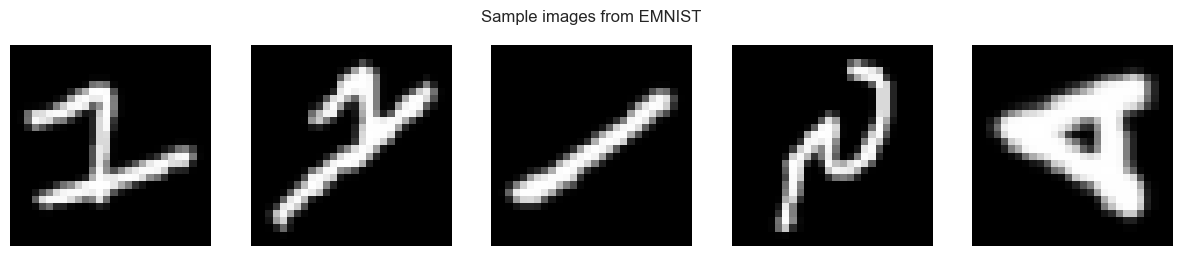

In [15]:
# lets inspect the images
idxs = np.random.choice(len(X_images), size=5, replace=False)
plt.figure(figsize=(15, 3))
plt.title("Sample images from EMNIST")
plt.axis('off')
for i, idx in enumerate(idxs):
    plt.subplot(1, 5, i + 1)
    
    img = X_images[idx].reshape(28, 28)
    
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.show()

In [16]:
print(f"Shape of X_images: {X_images.shape}\nShape of y_images: {y_images.shape}")
num_clases = len(np.unique(y_images))
print(f"Number of classes: {num_clases}")
X_images = X_images.reshape(X_images.shape[0], -1).astype(np.float32)
X_images /= np.float32(255.0)
print(f"Pixel min_value: {X_images.min()}\nPixel max_value: {X_images.max()}")

Shape of X_images: (809555, 28, 28)
Shape of y_images: (809555,)
Number of classes: 47
Pixel min_value: 0.0
Pixel max_value: 1.0


Parece que hay 47 clases de números (y letras dado que trabajamos con Extended MNIST). Esto es algo importante ya que las redes usarán Binary Cross Entropy (BCE) y de alguna forma tiene que estar encodeado numéricamente cada label (más allá del número de clase con el que ya se cuenta). La idea es hacer one hot encoding. Si la complejidad computacional se ve alterada fuertemente por el aumento de la dimensión del dataset, entonces vamos a evaluar otro tipo de encoding.

In [17]:
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X_images,
    y_images,
    train_ratio=0.70,
    val_ratio=0.15
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (566667, 784) (566667,)
Validation: (121410, 784) (121410,)
Test: (121478, 784) (121478,)


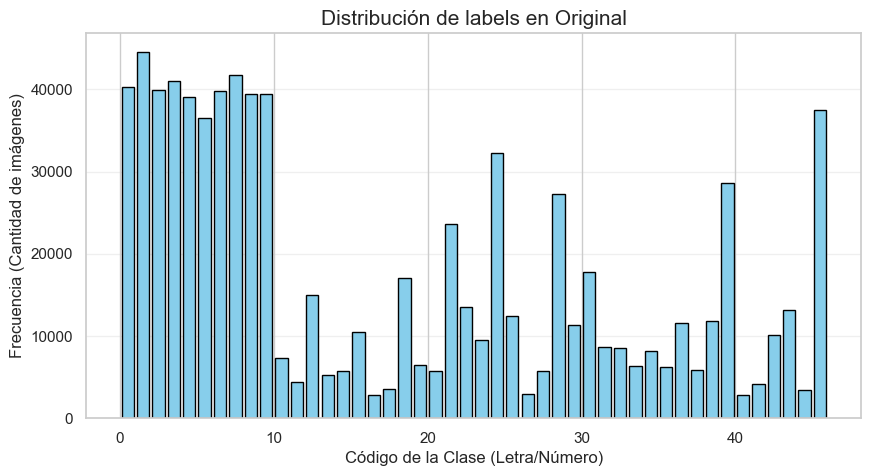

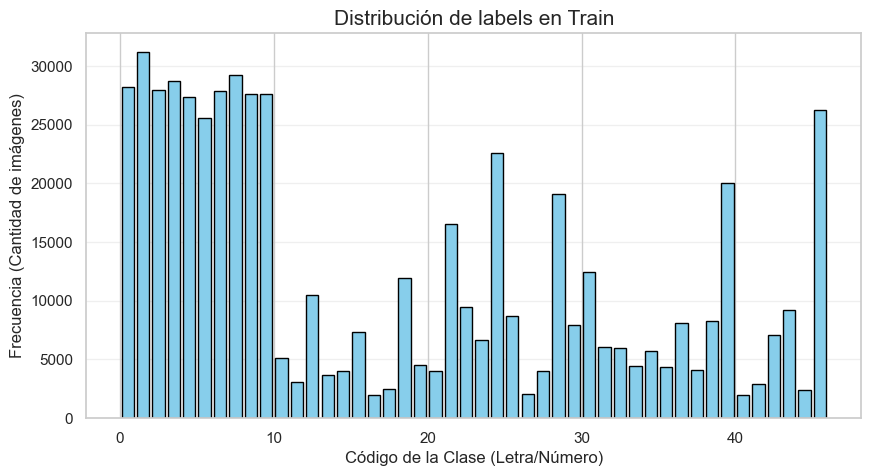

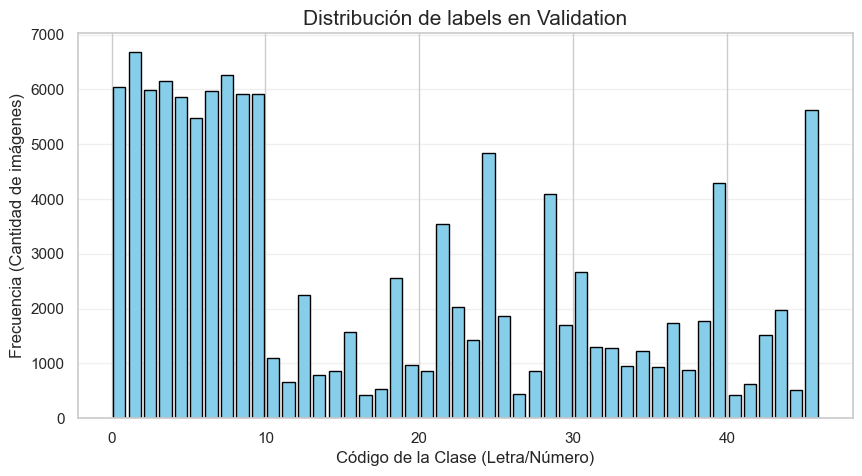

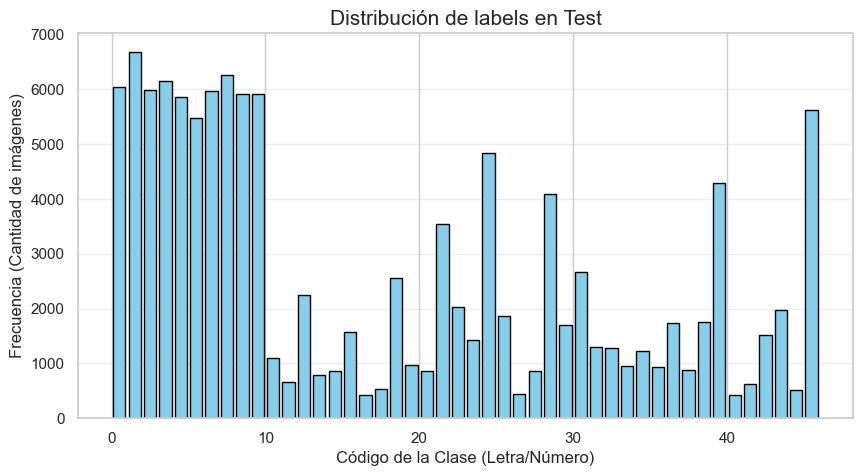

In [18]:
show_label_distribution(y_images, "Original")
show_label_distribution(y_train, "Train")
show_label_distribution(y_val, "Validation")
show_label_distribution(y_test, "Test")

Lo que nos muestran los gráficos, la distribución de las categorías del target se mantiene, por lo cual garantizamos una estratificación representativa para el entrenamiento, validación y testeo. Claramente hay un desbalance de clases que imapctará negativamente en la performance de los modelos.

In [19]:
X_train_flat = flatten_images(X_train)
X_val_flat = flatten_images(X_val)
X_test_flat = flatten_images(X_test)

assert X_train_flat.shape[1] == 784
assert X_val_flat.shape[1] == 784
assert X_test_flat.shape[1] == 784

In [20]:
num_classes = len(np.unique(y_images))
train_size = X_train_flat.shape[0]

y_train_one_hot = one_hot_encode(y_train, num_classes)
y_val_one_hot = one_hot_encode(y_val, num_classes)
y_test_one_hot = one_hot_encode(y_test, num_classes)

Finalmente, flateamos y encodeamos el target para poder usar en la CE

## 2. Implementación y Entrenamiento de una Red Neuronal Básica

### a) Implementar una red neuronal Multi-layer perceptron (MLP) con $L$ capas ocultas, cada una con $M(l)$ nodos, utilizando ReLU en las capas ocultas y activación softmax en la capa de salida.
### b) Implementar un algoritmo para entrenar dicha red, mediante backpropagation y gradiente descendente estándar, utilizando como función de costo la cross-entropy. NOTA: El algoritmo backpropagation debe adaptarse al caso de clasificación multiclase con función de activación softmax en la salida y función de costo cross-entropy.
### c) Entrenar una red neuronal con $2$ capas ocultas, con $128$ y $64$ nodos respectivamente, y graficar la evolución de la función de costo (cross-entropy) sobre los conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a este modelo M0.
### d) Reportar las siguientes métricas de performance, sobre los conjuntos de entrenamiento y validación, para el modelo base entrenado: Accuracy, Cross-Entropy, Matriz de Confusión, F1-Score Macro
---

Epoch 000 | LR: 0.001000 | Train CE: 3.9162 | Val CE: 3.9169
Epoch 010 | LR: 0.001000 | Train CE: 3.9028 | Val CE: 3.9036
Epoch 020 | LR: 0.001000 | Train CE: 3.8901 | Val CE: 3.8909
Epoch 030 | LR: 0.001000 | Train CE: 3.8781 | Val CE: 3.8789
Epoch 040 | LR: 0.001000 | Train CE: 3.8665 | Val CE: 3.8674


Model                     M0
Implementation    Base model
Time [sec]        631.231378
Train CE            3.856583
Val CE              3.857467
Train Accuracy      0.050986
Val Accuracy        0.050614
Train F1 Macro      0.009664
Val F1 Macro        0.009395
dtype: object

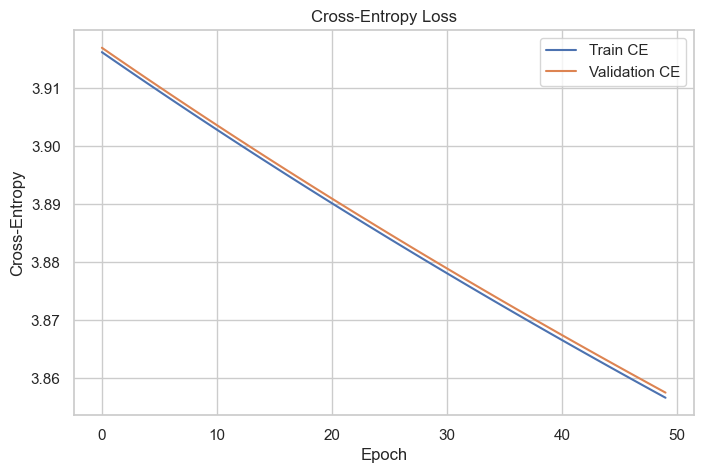

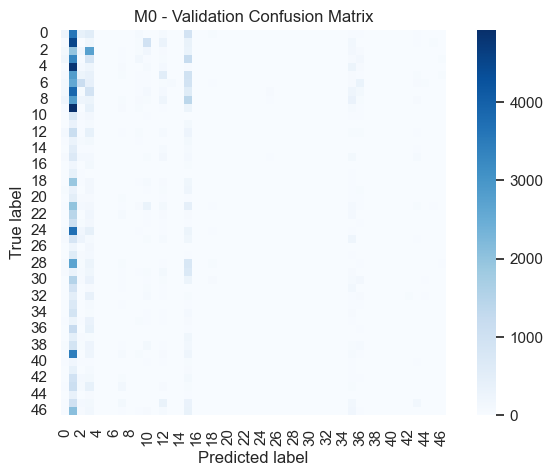

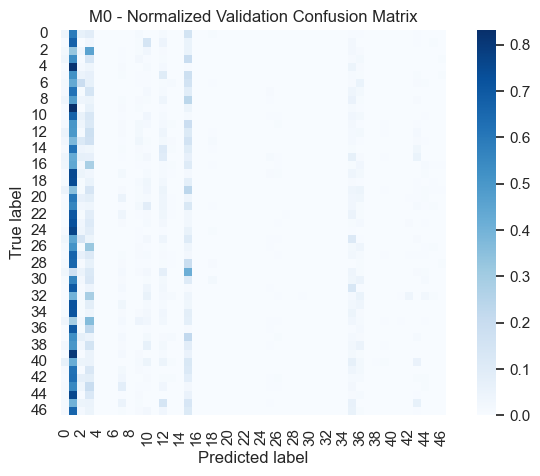

In [21]:
M0 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_M0, history_M0 = train_and_evaluate_model(
    model_name="M0",
    implementation="Base model",
    model=M0,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    plot=True,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

Claramente una red muy simple, que a pesar de entrenar 50 epochs no presenta mejoras significativas en la función de pérdida (CE) y que performativamente es muy malo, no llega a 0.001 de F1-Macro. La matriz de confunción muestra que el modelo está altamente sesgada por la clasificación de la clase 1 y la 15.

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada
### a) Implementar las siguientes mejoras al algoritmo de entrenamiento, y para cada una reportar el efecto observado sobre el tiempo de entrenamiento y la performance del modelo resultante.
- Rate scheduling lineal (con saturación) y exponencial.
- Mini-batch stochastic gradient descent.
- Optimizador Adam.
- Regularización (L2, Early Stopping)
- Opcional: Batch normalization.
- Opcional: Label smoothing.
- Opcional: Gradient clipping.
---

### A1 — Mini-batch SGD

In [14]:
a1 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a1, history_a1 = train_and_evaluate_model(
    model_name="A1",
    implementation="Mini-batch SGD",
    model=a1,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": 128,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

Epoch 000 | LR: 0.001000 | Train CE: 2.2237 | Val CE: 2.2222
Epoch 010 | LR: 0.001000 | Train CE: 0.9293 | Val CE: 0.9313
Epoch 020 | LR: 0.001000 | Train CE: 0.7633 | Val CE: 0.7685
Epoch 030 | LR: 0.001000 | Train CE: 0.6732 | Val CE: 0.6802
Epoch 040 | LR: 0.001000 | Train CE: 0.6162 | Val CE: 0.6246


### A2 — Adam

In [15]:
a2 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a2, history_a2 = train_and_evaluate_model(
    model_name="A2",
    implementation="Adam",
    model=a2,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "adam",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

Epoch 000 | LR: 0.001000 | Train CE: 3.8206 | Val CE: 3.8216
Epoch 010 | LR: 0.001000 | Train CE: 3.0333 | Val CE: 3.0339
Epoch 020 | LR: 0.001000 | Train CE: 2.2985 | Val CE: 2.2979
Epoch 030 | LR: 0.001000 | Train CE: 1.8666 | Val CE: 1.8654
Epoch 040 | LR: 0.001000 | Train CE: 1.5726 | Val CE: 1.5703


### A3 — L2 + early stopping

In [16]:
a3 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a3, history_a3 = train_and_evaluate_model(
    model_name="A3",
    implementation="L2 + early stopping",
    model=a3,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 1e-4,
        "early_stopping": True,
        "verbose": True
    }
)

Epoch 000 | LR: 0.001000 | Train CE: 3.9855 | Val CE: 3.9863
Epoch 010 | LR: 0.001000 | Train CE: 3.9723 | Val CE: 3.9731
Epoch 020 | LR: 0.001000 | Train CE: 3.9597 | Val CE: 3.9604
Epoch 030 | LR: 0.001000 | Train CE: 3.9476 | Val CE: 3.9483
Epoch 040 | LR: 0.001000 | Train CE: 3.9360 | Val CE: 3.9368


### A4 — Exponential LR Scheduler

In [17]:
a4 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a4, history_a4 = train_and_evaluate_model(
    model_name="A4",
    implementation="Exponential LR Scheduler",
    model=a4,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": "exponential",
        "initial_lr": 0.001,
        "final_lr": 1e-5,
        "decay_rate": 0.97,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

Epoch 000 | LR: 0.001000 | Train CE: 4.0038 | Val CE: 4.0043
Epoch 010 | LR: 0.000737 | Train CE: 3.9884 | Val CE: 3.9889
Epoch 020 | LR: 0.000544 | Train CE: 3.9777 | Val CE: 3.9782
Epoch 030 | LR: 0.000401 | Train CE: 3.9701 | Val CE: 3.9706
Epoch 040 | LR: 0.000296 | Train CE: 3.9646 | Val CE: 3.9651


### A5 — Batch Normalization

In [18]:
a5 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes],
    use_batch_norm=True
)

result_a5, history_a5 = train_and_evaluate_model(
    model_name="A5",
    implementation="Batch Normalization",
    model=a5,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "verbose": True
    }
)

Epoch 000 | LR: 0.001000 | Train CE: 3.9798 | Val CE: 3.9798
Epoch 010 | LR: 0.001000 | Train CE: 4.0085 | Val CE: 4.0077
Epoch 020 | LR: 0.001000 | Train CE: 4.1120 | Val CE: 4.1111
Epoch 030 | LR: 0.001000 | Train CE: 4.1874 | Val CE: 4.1863
Epoch 040 | LR: 0.001000 | Train CE: 4.2153 | Val CE: 4.2142


### A6 — Label Smoothing

In [19]:
a6 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a6, history_a6 = train_and_evaluate_model(
    model_name="A6",
    implementation="Label Smoothing",
    model=a6,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "label_smoothing": 0.05,
        "verbose": True
    }
)

Epoch 000 | LR: 0.001000 | Train CE: 3.9277 | Val CE: 3.9282
Epoch 010 | LR: 0.001000 | Train CE: 3.9163 | Val CE: 3.9167
Epoch 020 | LR: 0.001000 | Train CE: 3.9053 | Val CE: 3.9056
Epoch 030 | LR: 0.001000 | Train CE: 3.8947 | Val CE: 3.8950
Epoch 040 | LR: 0.001000 | Train CE: 3.8846 | Val CE: 3.8849


### A7 — Gradient Clipping

In [20]:
a7 = MLPClassifier(
    layer_sizes=[784, 128, 64, num_classes]
)

result_a7, history_a7 = train_and_evaluate_model(
    model_name="A7",
    implementation="Gradient Clipping",
    model=a7,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config={
        "epochs": 50,
        "batch_size": train_size,
        "optimizer": "gd",
        "scheduler": None,
        "initial_lr": 0.001,
        "l2_lambda": 0.0,
        "early_stopping": False,
        "gradient_clip_norm": 5.0,
        "verbose": True
    }
)

Epoch 000 | LR: 0.001000 | Train CE: 4.0012 | Val CE: 4.0018
Epoch 010 | LR: 0.001000 | Train CE: 3.9816 | Val CE: 3.9821
Epoch 020 | LR: 0.001000 | Train CE: 3.9636 | Val CE: 3.9641
Epoch 030 | LR: 0.001000 | Train CE: 3.9470 | Val CE: 3.9475
Epoch 040 | LR: 0.001000 | Train CE: 3.9317 | Val CE: 3.9322


In [ ]:
ablation_table = pd.DataFrame([
    result_M0,
    result_a1,
    result_a2,
    result_a3,
    result_a4,
    result_a5,
    result_a6,
    result_a7
])
ablation_table.to_csv("../results/results_ablation.csv", index=False)
ablation_table

,Model,Implementation,Time [sec],Train CE,Val CE,Train Accuracy,Val Accuracy,Train F1 Macro,Val F1 Macro
0,M0,Base model,568.508082,3.986833,3.986245,0.042572,0.043851,0.015588,0.015870
1,A1,Mini-batch SGD,481.065922,0.581876,0.591830,0.820942,0.820007,0.752303,0.751287
2,A2,Adam,562.317533,1.375170,1.373505,0.640724,0.640277,0.433671,0.434273
3,A3,L2 + early stopping,552.912019,3.926004,3.926751,0.024372,0.024833,0.012307,0.012539
4,A4,Exponential LR Scheduler,557.179307,3.961034,3.961471,0.014732,0.014019,0.008002,0.007874
5,A5,Batch Normalization,937.253998,4.214209,4.213012,0.046064,0.045458,0.022395,0.021851
6,A6,Label Smoothing,542.561866,3.875816,3.876040,0.022925,0.022906,0.010152,0.010407
7,A7,Gradient Clipping,533.850381,3.918748,3.919230,0.029726,0.029932,0.009665,0.009469


Los resultados sugieren que las mejoras más significativas en términos de performance provienen del uso de mini-batches y del optimizador Adam. Esto es esperable, ya que el entrenamiento por batches introduce actualizaciones más frecuentes y eficientes que el gradiente descendente completo, mientras que Adam adapta la tasa de aprendizaje de cada parámetro mediante estimaciones de primer y segundo momento del gradiente, acelerando y estabilizando la convergencia. Por otro lado, Batch Normalization muestra cierta mejora respecto del modelo base, pero implica un costo computacional considerable, con un tiempo de entrenamiento cercano al doble. Por esta razón, no resulta una prioridad para la siguiente etapa de búsqueda de hiperparámetros, al menos en una primera exploración donde conviene priorizar cambios de arquitectura, optimización y control del sobreajuste.

### b) Explorar cambios en la arquitectura de la red (es decir, la cantidad de capas ocultas y unidades ocultas por capa), y en los hiperparámetros (cada uno de los ítems en la lista anterior tiene parámetros que se pueden variar), y determinar la configuración que funcione mejor (menor error de validación). Llamaremos a este modelo M1.
---

Sobre múltiples combinaciones de hiperparámetros lo estadísticamente correcto sería hacer cross validation. Por ello, se realizó una búsqueda de hiperparámetros mediante K-Fold estratificado sobre el conjunto de desarrollo, construido a partir de train y validation. Los folds se generaron preservando la distribución de clases. La selección de M1 se hizo minimizando la cross-entropy promedio de validación entre folds. El conjunto de test se mantuvo aislado para la comparación final de modelos.

In [12]:
# Concat for later G-Search
X_dev = np.concatenate([X_train_flat, X_val_flat], axis=0)
y_dev_one_hot = np.concatenate([y_train_one_hot, y_val_one_hot], axis=0)
X_dev = X_dev.astype(np.float32, copy=False)
y_dev_one_hot = y_dev_one_hot.astype(np.float32, copy=False)

In [ ]:
model_grid = {
    "layer_sizes": [
        [784, 128, 64, num_classes],
        [784, 256, 128, num_classes],
    ],
    "use_batch_norm": [False],
}
fit_grid = {
    "epochs": [40],
    "batch_size": [128, 256],
    "optimizer": ["adam"],
    "scheduler": [None],
    "initial_lr": [1e-3],
    "final_lr": [1e-5],
    "decay_rate": [0.97],
    "l2_lambda": [0.0, 1e-4],
    "early_stopping": [True],
    "patience": [5],
    "label_smoothing": [0],
    "gradient_clip_norm": [None],
    "verbose": [False],
}
grid_configs = build_grid_configs(model_grid, fit_grid)
grid_results = grid_search_cv_mlp(
    X=X_dev,
    y_one_hot=y_dev_one_hot,
    model_cls=MLPClassifier,
    grid_configs=grid_configs,
    k_folds=3
)
grid_results["summary"]

In [ ]:
best_model_kwargs = grid_results["best_model_kwargs"]
best_fit_kwargs = grid_results["best_fit_kwargs"]

print("Best model kwargs:")
print(best_model_kwargs)

print("\nBest fit kwargs:")
print(best_fit_kwargs)

print("\nBest mean validation CE:")
print(grid_results["best_score"])
grid_results.to_csv("../results/results_gsearch1.csv", index=False)

Best model kwargs:
{'layer_sizes': [784, 256, 128, 47], 'use_batch_norm': False}

Best fit kwargs:
{'epochs': 40, 'batch_size': 256, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.0001, 'early_stopping': True, 'patience': 5, 'label_smoothing': 0, 'gradient_clip_norm': None, 'verbose': False}

Best mean validation CE:
0.3467576808416967


In [ ]:
model_grid_refine = {
    "layer_sizes": [
        [784, 256, 128, num_classes],
        [784, 384, 192, num_classes],
        [784, 256, 128, 64, num_classes]
    ],
    "use_batch_norm": [False],
}
fit_grid_refine = {
    "epochs": [40],
    "batch_size": [512, 1024],
    "optimizer": ["adam"],
    "scheduler": [None],
    "initial_lr": [1e-3],
    "final_lr": [1e-5],
    "decay_rate": [0.97],
    "l2_lambda": [1e-4],
    "early_stopping": [True],
    "patience": [5],
    "label_smoothing": [0.0],
    "gradient_clip_norm": [None],
    "verbose": [True]
}
grid_configs = build_grid_configs(model_grid_refine, fit_grid_refine)
grid_results = grid_search_cv_mlp(
    X=X_dev,
    y_one_hot=y_dev_one_hot,
    model_cls=MLPClassifier,
    grid_configs=grid_configs,
    k_folds=3
)
grid_results["summary"]


Config 1/6
Model: {'layer_sizes': [784, 256, 128, 47], 'use_batch_norm': False}
Fit: {'epochs': 40, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.0001, 'early_stopping': True, 'patience': 5, 'label_smoothing': 0.0, 'gradient_clip_norm': None}
Epoch 000 | LR: 0.001000 | Train CE: 0.4642 | Val CE: 0.4831
Epoch 010 | LR: 0.001000 | Train CE: 0.2638 | Val CE: 0.3495
Early stopping at epoch 016
Fold 1 | Val CE: 0.3477 | Val Acc: 0.8814 | Val F1: 0.8499
Epoch 000 | LR: 0.001000 | Train CE: 0.4736 | Val CE: 0.4900
Epoch 010 | LR: 0.001000 | Train CE: 0.2629 | Val CE: 0.3445
Early stopping at epoch 014
Fold 2 | Val CE: 0.3430 | Val Acc: 0.8811 | Val F1: 0.8444
Epoch 000 | LR: 0.001000 | Train CE: 0.4617 | Val CE: 0.4750
Epoch 010 | LR: 0.001000 | Train CE: 0.2649 | Val CE: 0.3461
Early stopping at epoch 013
Fold 3 | Val CE: 0.3437 | Val Acc: 0.8815 | Val F1: 0.8488

Config 2/6
Model: {'layer_sizes': [784, 

,config_id,model_kwargs,fit_kwargs,mean_train_ce,mean_val_ce,std_val_ce,mean_val_accuracy,std_val_accuracy,mean_val_f1_macro,std_val_f1_macro,mean_time,total_time,n_folds
0,3,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 40, 'batch_size': 512, 'optimizer':...",0.263158,0.336883,0.001880,0.882132,0.000244,0.850083,0.002429,283.116511,849.349532,3
1,4,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 40, 'batch_size': 1024, 'optimizer'...",0.256727,0.336890,0.004028,0.882513,0.001199,0.852865,0.001874,277.433129,832.299386,3
2,1,"{'layer_sizes': [784, 256, 128, 47], 'use_batc...","{'epochs': 40, 'batch_size': 512, 'optimizer':...",0.266440,0.344829,0.002048,0.881337,0.000146,0.847693,0.002371,251.821683,755.465050,3
3,5,"{'layer_sizes': [784, 256, 128, 64, 47], 'use_...","{'epochs': 40, 'batch_size': 512, 'optimizer':...",0.260460,0.348946,0.002422,0.879162,0.000864,0.847762,0.000432,284.612648,853.837943,3
4,2,"{'layer_sizes': [784, 256, 128, 47], 'use_batc...","{'epochs': 40, 'batch_size': 1024, 'optimizer'...",0.265530,0.349083,0.001275,0.879769,0.000645,0.847036,0.001653,254.056796,762.170389,3
5,6,"{'layer_sizes': [784, 256, 128, 64, 47], 'use_...","{'epochs': 40, 'batch_size': 1024, 'optimizer'...",0.271365,0.350698,0.001242,0.879464,0.000838,0.844861,0.000313,239.309884,717.929653,3


In [ ]:
best_model_kwargs = grid_results["best_model_kwargs"]
best_fit_kwargs = grid_results["best_fit_kwargs"]

print("Best model kwargs:")
print(best_model_kwargs)

print("\nBest fit kwargs:")
print(best_fit_kwargs)

print("\nBest mean validation CE:")
print(grid_results["best_score"])
grid_results.to_csv("../results/results_gsearch2.csv", index=False)

Best model kwargs:
{'layer_sizes': [784, 384, 192, 47], 'use_batch_norm': False}

Best fit kwargs:
{'epochs': 40, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.0001, 'early_stopping': True, 'patience': 5, 'label_smoothing': 0.0, 'gradient_clip_norm': None}

Best mean validation CE:
0.3368825308791779


In [21]:
model_grid_refine_regularization = {
    "layer_sizes": [
        [784, 384, 192, num_classes],        # best actual, control
        [784, 512, 192, num_classes],        # más capacidad inicial
        [784, 512, 256, num_classes],        # más capacidad balanceada
        [784, 384, 192, 96, num_classes],    # más profundidad
    ],
    "use_batch_norm": [False],
}
fit_grid_refine_regularization = {
    "epochs": [40],
    "batch_size": [512],
    "optimizer": ["adam"],
    "scheduler": [None],
    "initial_lr": [1e-3],
    "final_lr": [1e-5],
    "decay_rate": [0.97],
    "l2_lambda": [1e-3],
    "early_stopping": [True],
    "patience": [5],
    "label_smoothing": [0.0],
    "gradient_clip_norm": [None]
}
grid_configs = build_grid_configs(model_grid_refine_regularization, fit_grid_refine_regularization)
grid_results = grid_search_cv_mlp(
    X=X_dev,
    y_one_hot=y_dev_one_hot,
    model_cls=MLPClassifier,
    grid_configs=grid_configs,
    k_folds=2
)
grid_results["summary"]


Config 1/4
Model: {'layer_sizes': [784, 384, 192, 47], 'use_batch_norm': False}
Fit: {'epochs': 40, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.001, 'early_stopping': True, 'patience': 5, 'label_smoothing': 0.0, 'gradient_clip_norm': None}
Epoch 000 | LR: 0.001000 | Train CE: 0.4757 | Val CE: 0.4966
Epoch 010 | LR: 0.001000 | Train CE: 0.2362 | Val CE: 0.3558
Early stopping at epoch 012
Fold 1 | Val CE: 0.3518 | Val Acc: 0.8778 | Val F1: 0.8481
Epoch 000 | LR: 0.001000 | Train CE: 0.4640 | Val CE: 0.4849
Epoch 010 | LR: 0.001000 | Train CE: 0.2372 | Val CE: 0.3572
Early stopping at epoch 012
Fold 2 | Val CE: 0.3508 | Val Acc: 0.8792 | Val F1: 0.8467

Config 2/4
Model: {'layer_sizes': [784, 512, 192, 47], 'use_batch_norm': False}
Fit: {'epochs': 40, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.001, 'early_stop

,config_id,model_kwargs,fit_kwargs,mean_train_ce,mean_val_ce,std_val_ce,mean_val_accuracy,std_val_accuracy,mean_val_f1_macro,std_val_f1_macro,mean_time,total_time,n_folds
0,3,"{'layer_sizes': [784, 512, 256, 47], 'use_batc...","{'epochs': 40, 'batch_size': 512, 'optimizer':...",0.225781,0.345797,0.002439,0.881502,0.000959,0.851710,0.001067,392.694276,785.388552,2
1,2,"{'layer_sizes': [784, 512, 192, 47], 'use_batc...","{'epochs': 40, 'batch_size': 512, 'optimizer':...",0.237049,0.345893,0.001040,0.880884,0.000658,0.849116,0.000115,340.378936,680.757871,2
2,1,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 40, 'batch_size': 512, 'optimizer':...",0.259935,0.351271,0.000501,0.878519,0.000695,0.847411,0.000670,251.078263,502.156527,2
3,4,"{'layer_sizes': [784, 384, 192, 96, 47], 'use_...","{'epochs': 40, 'batch_size': 512, 'optimizer':...",0.249299,0.353850,0.001273,0.878049,0.000172,0.844894,0.002100,276.225623,552.451246,2


In [ ]:
best_model_kwargs = grid_results["best_model_kwargs"]
best_fit_kwargs = grid_results["best_fit_kwargs"]

print("Best model kwargs:")
print(best_model_kwargs)

print("\nBest fit kwargs:")
print(best_fit_kwargs)

print("\nBest mean validation CE:")
print(grid_results["best_score"])
grid_results.to_csv("../results/results_gsearch3.csv", index=False)

Best model kwargs:
{'layer_sizes': [784, 512, 256, 47], 'use_batch_norm': False}

Best fit kwargs:
{'epochs': 40, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.001, 'early_stopping': True, 'patience': 5, 'label_smoothing': 0.0, 'gradient_clip_norm': None}

Best mean validation CE:
0.34579744604868123


In [24]:
model_grid_refine = {
    "layer_sizes": [[784, 384, 192, num_classes]],
    "use_batch_norm": [False],
}
fit_grid_refine = {
    "epochs": [60],
    "batch_size": [512],
    "optimizer": ["adam"],
    "scheduler": ["exponential", "linear"],
    "initial_lr": [1e-3],
    "final_lr": [1e-5],
    "decay_rate": [0.99, 0.97],
    "l2_lambda": [5e-4],
    "early_stopping": [True],
    "patience": [10],
    "label_smoothing": [0.03],
    "gradient_clip_norm": [None],
    "verbose": [True],
}
grid_configs = build_grid_configs(model_grid_refine, fit_grid_refine)
grid_results = grid_search_cv_mlp(
    X=X_dev,
    y_one_hot=y_dev_one_hot,
    model_cls=MLPClassifier,
    grid_configs=grid_configs,
    k_folds=2
)
grid_results["summary"]



Config 1/4
Model: {'layer_sizes': [784, 384, 192, 47], 'use_batch_norm': False}
Fit: {'epochs': 60, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': 'exponential', 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.99, 'l2_lambda': 0.0005, 'early_stopping': True, 'patience': 10, 'label_smoothing': 0.03, 'gradient_clip_norm': None, 'verbose': True}
Epoch 000 | LR: 0.001000 | Train CE: 0.4972 | Val CE: 0.5174
Epoch 010 | LR: 0.000904 | Train CE: 0.2700 | Val CE: 0.3562
Epoch 020 | LR: 0.000818 | Train CE: 0.2256 | Val CE: 0.3580
Early stopping at epoch 022
Fold 1 | Val CE: 0.3536 | Val Acc: 0.8840 | Val F1: 0.8500
Epoch 000 | LR: 0.001000 | Train CE: 0.4924 | Val CE: 0.5103
Epoch 010 | LR: 0.000904 | Train CE: 0.2724 | Val CE: 0.3602
Epoch 020 | LR: 0.000818 | Train CE: 0.2278 | Val CE: 0.3593
Early stopping at epoch 024
Fold 2 | Val CE: 0.3530 | Val Acc: 0.8832 | Val F1: 0.8516

Config 2/4
Model: {'layer_sizes': [784, 384, 192, 47], 'use_batch_norm': False}
Fit: {'epochs': 60,

,config_id,model_kwargs,fit_kwargs,mean_train_ce,mean_val_ce,std_val_ce,mean_val_accuracy,std_val_accuracy,mean_val_f1_macro,std_val_f1_macro,mean_time,total_time,n_folds
0,2,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.234594,0.350973,0.000598,0.885344,0.000129,0.855819,0.000204,520.867027,1041.734055,2
1,3,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.248781,0.351968,0.000439,0.885016,0.000002,0.855110,0.002279,457.296964,914.593929,2
2,4,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.248159,0.352070,0.002003,0.884655,0.000344,0.854441,0.002675,442.016885,884.033770,2
3,1,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.251434,0.353270,0.000314,0.883594,0.000427,0.850773,0.000783,457.683940,915.367879,2


In [ ]:
best_model_kwargs = grid_results["best_model_kwargs"]
best_fit_kwargs = grid_results["best_fit_kwargs"]

print("Best model kwargs:")
print(best_model_kwargs)

print("\nBest fit kwargs:")
print(best_fit_kwargs)

print("\nBest mean validation CE:")
print(grid_results["best_score"])
grid_results.to_csv("../results/results_gsearch3.csv", index=False)

Best model kwargs:
{'layer_sizes': [784, 384, 192, 47], 'use_batch_norm': False}

Best fit kwargs:
{'epochs': 60, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': 'exponential', 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.0005, 'early_stopping': True, 'patience': 10, 'label_smoothing': 0.03, 'gradient_clip_norm': None, 'verbose': True}

Best mean validation CE:
0.3509730491380325


In [26]:
model_grid_final_check = {
    "layer_sizes": [[784, 384, 192, num_classes]],
    "use_batch_norm": [False],
}
fit_grid_final_check = {
    "epochs": [60],
    "batch_size": [512],
    "optimizer": ["adam"],
    "scheduler": [None],
    "initial_lr": [1e-3, 5e-4],
    "final_lr": [1e-5],
    "decay_rate": [0.97],
    "l2_lambda": [1e-2, 1e-3, 1e-4],
    "early_stopping": [True],
    "patience": [6],
    "label_smoothing": [0, 0.03],
    "gradient_clip_norm": [None],
    "verbose": [False],
}
grid_configs = build_grid_configs(model_grid_final_check, fit_grid_final_check)
grid_results = grid_search_cv_mlp(
    X=X_dev,
    y_one_hot=y_dev_one_hot,
    model_cls=MLPClassifier,
    grid_configs=grid_configs,
    k_folds=2
)
grid_results["summary"]


Config 1/12
Model: {'layer_sizes': [784, 384, 192, 47], 'use_batch_norm': False}
Fit: {'epochs': 60, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.01, 'early_stopping': True, 'patience': 6, 'label_smoothing': 0, 'gradient_clip_norm': None, 'verbose': False}
Fold 1 | Val CE: 0.3451 | Val Acc: 0.8795 | Val F1: 0.8481
Fold 2 | Val CE: 0.3463 | Val Acc: 0.8806 | Val F1: 0.8487

Config 2/12
Model: {'layer_sizes': [784, 384, 192, 47], 'use_batch_norm': False}
Fit: {'epochs': 60, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.01, 'early_stopping': True, 'patience': 6, 'label_smoothing': 0.03, 'gradient_clip_norm': None, 'verbose': False}
Fold 1 | Val CE: 0.3506 | Val Acc: 0.8860 | Val F1: 0.8565
Fold 2 | Val CE: 0.3474 | Val Acc: 0.8865 | Val F1: 0.8585

Config 3/12
Model: {'layer_sizes': [784, 384, 192, 47], 'use_batch

,config_id,model_kwargs,fit_kwargs,mean_train_ce,mean_val_ce,std_val_ce,mean_val_accuracy,std_val_accuracy,mean_val_f1_macro,std_val_f1_macro,mean_time,total_time,n_folds
0,1,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.251811,0.345696,0.000560,0.880034,0.000579,0.848380,0.000282,285.992696,571.985392,2
1,7,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.237418,0.346236,0.001650,0.880326,0.000553,0.849467,0.000533,415.636716,831.273432,2
2,2,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.241441,0.348989,0.001585,0.886225,0.000239,0.857504,0.000962,473.443307,946.886613,2
3,3,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.241145,0.349729,0.001523,0.880306,0.000129,0.847775,0.000538,288.305337,576.610674,2
4,9,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.251265,0.350293,0.000885,0.880019,0.000273,0.846798,0.001667,351.388520,702.777040,2
5,11,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.252245,0.350591,0.000453,0.878983,0.000603,0.847377,0.000999,352.780052,705.560104,2
6,4,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.252629,0.351984,0.000761,0.884328,0.000700,0.853331,0.003312,351.760599,703.521199,2
7,6,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.247879,0.352968,0.001528,0.884256,0.000507,0.857080,0.000673,378.473244,756.946487,2
8,5,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.255662,0.353217,0.001197,0.878172,0.000114,0.846149,0.000434,261.359368,522.718736,2
9,8,"{'layer_sizes': [784, 384, 192, 47], 'use_batc...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.255406,0.353377,0.000827,0.884360,0.000371,0.855428,0.000987,522.975105,1045.950211,2


In [ ]:
best_model_kwargs = grid_results["best_model_kwargs"]
best_fit_kwargs = grid_results["best_fit_kwargs"]

print("Best model kwargs:")
print(best_model_kwargs)

print("\nBest fit kwargs:")
print(best_fit_kwargs)

print("\nBest mean validation CE:")
print(grid_results["best_score"])
grid_results.to_csv("../results/results_gsearch4.csv", index=False)

Best model kwargs:
{'layer_sizes': [784, 384, 192, 47], 'use_batch_norm': False}

Best fit kwargs:
{'epochs': 60, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.01, 'early_stopping': True, 'patience': 6, 'label_smoothing': 0, 'gradient_clip_norm': None, 'verbose': False}

Best mean validation CE:
0.3456963310580486


La búsqueda de hiperparámetros nos deja el mejor modelo como aquel con $Mean_{CE_{Val}}\approx0.3369$. Las búsquedas se basaron primero en combinar por un lado, Adam y SGD, las mejoras más prometedoras, junto con early stopping para cortar prematuramente en caso de overfitting. 

Cuando el entrenamiento cortó muy temprano se buscó una explicación, evaluando si el problema era un corte prematuro producido por una `patience` demasiado baja o si efectivamente la red estaba comenzando a sobreajustar. Para esto se repitió el entrenamiento de la mejor configuración parcial aumentando el máximo de épocas a 60 y la `patience` a 10. El resultado mostró que el modelo seguía deteniéndose alrededor de las épocas 18-19, por lo que el corte temprano no parecía deberse a una configuración demasiado agresiva de early stopping, sino a que la pérdida de validación se estabilizaba relativamente pronto.

Además, al observar las curvas de entrenamiento y validación (haciendo el entrenamiento de M1), se identificó un patrón típico de overfitting moderado: la pérdida de entrenamiento continuaba disminuyendo, mientras que la pérdida de validación alcanzaba un mínimo y luego comenzaba a estancarse o aumentar. Esto sugirió que la arquitectura tenía capacidad suficiente para aprender el conjunto de entrenamiento, pero que agregar más capacidad no necesariamente mejoraría la generalización.

A partir de esto, la búsqueda se orientó hacia ajustes locales alrededor de la mejor configuración encontrada. Primero se probó aumentar la capacidad de la red, pasando de arquitecturas como:

```python
[784, 256, 128, 47]
```

a configuraciones más grandes como:

```python
[784, 384, 192, 47]
[784, 512, 256, 47]
```

La arquitectura `[784, 384, 192, 47]` logró mejorar el desempeño de validación con `batch_size = 512`, Adam, `initial_lr = 1e-3`, `l2_lambda = 1e-4` y early stopping. Sin embargo, al seguir aumentando la capacidad hacia `[784, 512, 256, 47]`, incluso utilizando mayor regularización L2, el error de validación empeoró. Esto indicó que el modelo ya había alcanzado una zona razonable de capacidad y que seguir agrandando la red no era conveniente.

También se exploró el efecto del tamaño de batch. El pasaje de `batch_size = 256` a `batch_size = 512` mejoró la validación, probablemente porque generó actualizaciones más estables en combinación con Adam. Sin embargo, al probar `batch_size = 1024`, el desempeño empeoró, sugiriendo que un batch demasiado grande reducía el ruido útil del gradiente y afectaba la generalización.

Luego se probaron técnicas adicionales de regularización, incluyendo valores más altos de L2, label smoothing y schedulers lineal/exponencial. Estas combinaciones no lograron mejorar el mejor resultado previo. En particular, configuraciones con `l2_lambda = 5e-4` o `1e-3`, label smoothing y scheduler tendieron a aumentar la cross-entropy de validación. Esto sugiere que el modelo no requería una regularización mucho más fuerte, sino un balance moderado entre capacidad y penalización. Con lo cual, finalmente se obtuvieron los siguientes hiperparámetros correspondientes a la configuración de $Mean_{CE_{Val}}\approx0.3369$.

In [22]:
best_model_kwargs = {
    "layer_sizes": [784, 384, 192, 47],
    "use_batch_norm": False,
}
best_fit_kwargs = {
    "epochs": 60,
    "batch_size": 512,
    "optimizer": "adam",
    "scheduler": None,
    "initial_lr": 1e-3,
    "final_lr": 1e-5,
    "decay_rate": 0.97,
    "l2_lambda": 1e-4,
    "early_stopping": True,
    "patience": 10,
    "label_smoothing": 0.0,
    "gradient_clip_norm": None
}

## 4. Desarrollo de una Red Neuronal con PyTorch
### a) Utilizando PyTorch, entrenar una red neuronal con la arquitectura y los hiperparámetros hallados en el ejercicio anterior. Llamaremos a este modelo M2. Comparar la performance del modelo M1 y M2 para validar que los comportamientos de los modelos son parecidos.
---

Epoch 000 | LR: 0.001000 | Train CE: 0.4213 | Val CE: 0.4303
Epoch 010 | LR: 0.001000 | Train CE: 0.2308 | Val CE: 0.3252
Early stopping at epoch 016


Model                               M1
Implementation    Best G-search Tuning
Time [sec]                  502.704798
Train CE                      0.261003
Val CE                         0.32277
Train Accuracy                0.902142
Val Accuracy                  0.885495
Train F1 Macro                0.887109
Val F1 Macro                  0.857888
dtype: object

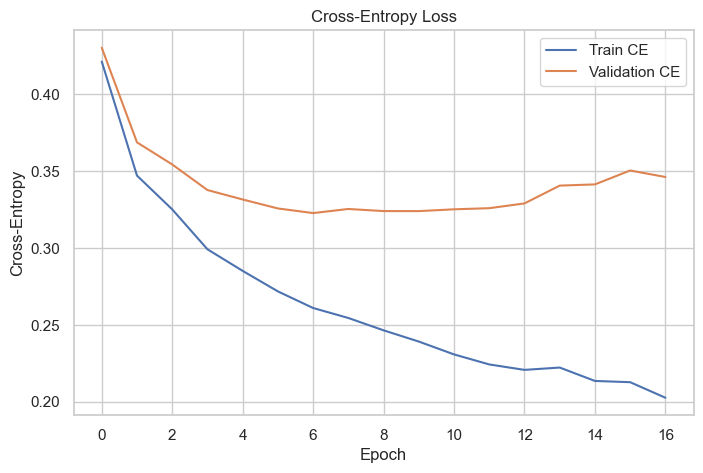

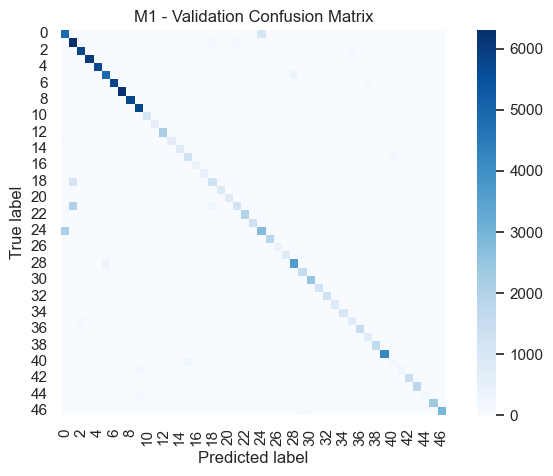

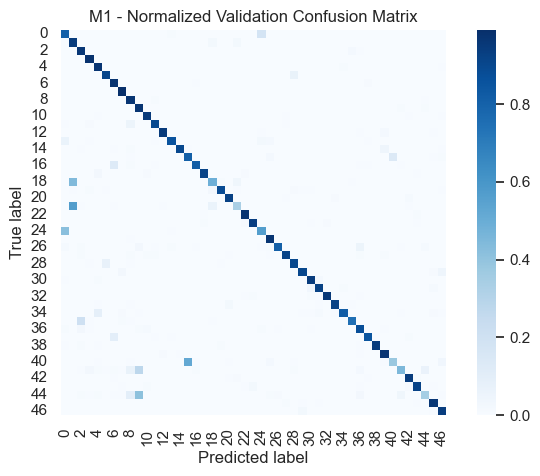

In [23]:
M1 = MLPClassifier(**best_model_kwargs)

result_M1, history_M1 = train_and_evaluate_model(
    model_name="M1",
    implementation="Best G-search Tuning",
    model=M1,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config=best_fit_kwargs,
    plot=True
)

Model                               M2
Implementation    Best params in Torch
Time [sec]                  349.017813
Train CE                      0.245139
Val CE                        0.321333
Train Accuracy                0.906019
Val Accuracy                  0.886994
Train F1 Macro                0.893128
Val F1 Macro                  0.860546
dtype: object

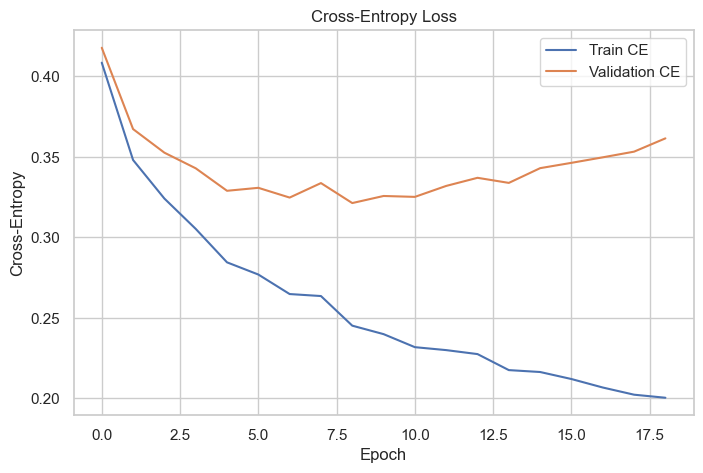

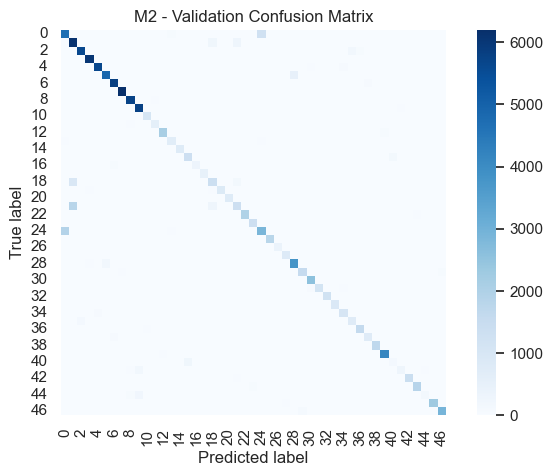

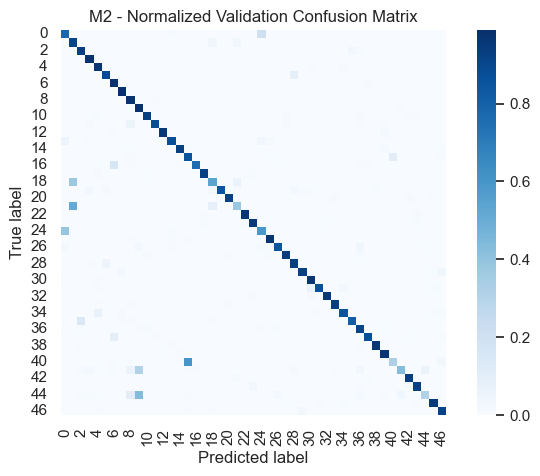

In [24]:
from src.torch_models import *  # Import our implementation of pytorch

M2 = TorchMLPClassifier(**best_model_kwargs)

result_M2, history_M2 = train_and_evaluate_torch_model(
    model_name="M2",
    implementation="Best params in Torch",
    model=M2,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config=best_fit_kwargs,
    plot=True
)

Los modelos son prácticamente idénticos, como era esperable. La implementación matemática de fondo es idéntica, con alguna optimización numérica en PyTorch, pero performativamente muy similares.

### b) Utilizando PyTorch, explorar cambios en la cantidad de capas ocultas y unidades ocultas por capa, y determinar la configuración que funcione mejor. Además de la arquitectura, se deberá experimentar con funciones de activación más modernas disponibles en torch.nn, tales como LeakyReLU, SiLU, Swish o GELU y estrategias de regularizacion adicionales como Dropout (ademas de las ya mencionadas previamente). Llamaremos a este modelo M3.
---

In [44]:
torch_model_grid = {
    "layer_sizes": [
        [784, 384, 192, 47],
    ],
    "activation_name": [
        "relu",
        "leaky_relu",
        "silu",
        "gelu",
    ],
    "dropout_rate": [
        0.1,
        0.2,
        0.3,
    ],
    "use_batch_norm": [
        False,
    ],
}
torch_fit_grid = {
    "epochs": [60],
    "batch_size": [512],
    "optimizer": ["adam"],
    "scheduler": [None],
    "initial_lr": [1e-3],
    "final_lr": [1e-5],
    "decay_rate": [0.97],
    "l2_lambda": [1e-4],
    "early_stopping": [True],
    "patience": [6],
    "label_smoothing": [0],
    "gradient_clip_norm": [None],
    "verbose": [True],
}
torch_grid_configs = build_grid_configs(
    model_grid=torch_model_grid,
    fit_grid=torch_fit_grid
)
M3_search_results = grid_search_cv_torch_mlp(
    X=X_train,
    y=y_train,
    model_cls=TorchMLPClassifier,
    grid_configs=torch_grid_configs,
    k_folds=2
)


Config 1/12
Model: {'layer_sizes': [784, 384, 192, 47], 'activation_name': 'relu', 'dropout_rate': 0.1, 'use_batch_norm': False}
Fit: {'epochs': 60, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.0001, 'early_stopping': True, 'patience': 6, 'label_smoothing': 0, 'gradient_clip_norm': None, 'verbose': True}
Epoch 000 | LR: 0.001000 | Train CE: 0.4823 | Val CE: 0.5061 | Val Acc: 0.8360
Epoch 010 | LR: 0.001000 | Train CE: 0.2474 | Val CE: 0.3390 | Val Acc: 0.8809
Early stopping at epoch 019
Fold 1 | Val CE: 0.3390 | Val Acc: 0.8832 | Val F1: 0.8513
Epoch 000 | LR: 0.001000 | Train CE: 0.4810 | Val CE: 0.4948 | Val Acc: 0.8397
Epoch 010 | LR: 0.001000 | Train CE: 0.2530 | Val CE: 0.3387 | Val Acc: 0.8821
Early stopping at epoch 019
Fold 2 | Val CE: 0.3323 | Val Acc: 0.8840 | Val F1: 0.8524

Config 2/12
Model: {'layer_sizes': [784, 384, 192, 47], 'activation_name': 'relu', 'dropout_rate': 0.2, 'use_batc

In [45]:
M3_summary = M3_search_results["summary"]
display(M3_summary)
best_M3_model_kwargs = M3_search_results["best_model_kwargs"]
best_M3_fit_kwargs = M3_search_results["best_fit_kwargs"]
print("Best model kwargs:")
print(best_M3_model_kwargs)

print("\nBest fit kwargs:")
print(best_M3_fit_kwargs)

print("\nBest mean validation CE:")
print(grid_results["best_score"])
M3_search_results.to_csv("../results/results_torch_gsearch.csv", index=False)

,config_id,model_kwargs,fit_kwargs,mean_train_ce,mean_val_ce,std_val_ce,mean_val_accuracy,std_val_accuracy,mean_val_f1_macro,std_val_f1_macro,mean_time,total_time,n_folds
0,9,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.235782,0.319401,0.002839,0.886533,0.000351,0.857241,0.000823,386.634483,773.268965,2
1,12,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.228809,0.322618,0.000942,0.885499,0.000546,0.853010,0.000602,472.042969,944.085938,2
2,8,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.229239,0.323992,0.002611,0.886154,0.000449,0.854935,0.000752,299.870021,599.740041,2
3,11,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.227327,0.325534,0.002274,0.885123,0.000847,0.854311,0.001560,310.016456,620.032911,2
4,3,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.238236,0.325884,0.000756,0.884883,0.000311,0.851563,0.002677,556.768477,1113.536954,2
5,2,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.231558,0.327687,0.002656,0.885107,0.000517,0.852914,0.001340,371.254073,742.508147,2
6,6,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.249778,0.328739,0.003233,0.884184,0.001539,0.848090,0.002070,443.367090,886.734181,2
7,5,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.238306,0.328826,0.003303,0.884498,0.000911,0.850944,0.001086,331.408154,662.816307,2
8,4,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.224927,0.332092,0.003074,0.884610,0.000620,0.853376,0.002674,281.722884,563.445767,2
9,7,"{'layer_sizes': [784, 384, 192, 47], 'activati...","{'epochs': 60, 'batch_size': 512, 'optimizer':...",0.226740,0.333512,0.003092,0.883773,0.000944,0.852127,0.001528,246.148296,492.296593,2


Best model kwargs:
{'layer_sizes': [784, 384, 192, 47], 'activation_name': 'silu', 'dropout_rate': 0.3, 'use_batch_norm': False}

Best fit kwargs:
{'epochs': 60, 'batch_size': 512, 'optimizer': 'adam', 'scheduler': None, 'initial_lr': 0.001, 'final_lr': 1e-05, 'decay_rate': 0.97, 'l2_lambda': 0.0001, 'early_stopping': True, 'patience': 6, 'label_smoothing': 0, 'gradient_clip_norm': None, 'verbose': True}

Best mean validation CE:
0.3456963310580486


Epoch 000 | LR: 0.001000 | Train CE: 0.4250 | Val CE: 0.4277 | Val Acc: 0.8550
Epoch 010 | LR: 0.001000 | Train CE: 0.2676 | Val CE: 0.3011 | Val Acc: 0.8908
Epoch 020 | LR: 0.001000 | Train CE: 0.2497 | Val CE: 0.2971 | Val Acc: 0.8923
Epoch 030 | LR: 0.001000 | Train CE: 0.2391 | Val CE: 0.2930 | Val Acc: 0.8942
Early stopping at epoch 037


Model                              M3
Implementation    Best G-Search Torch
Time [sec]                 864.369848
Train CE                     0.238016
Val CE                        0.29222
Train Accuracy               0.908004
Val Accuracy                 0.893707
Train F1 Macro               0.888408
Val F1 Macro                 0.863269
dtype: object

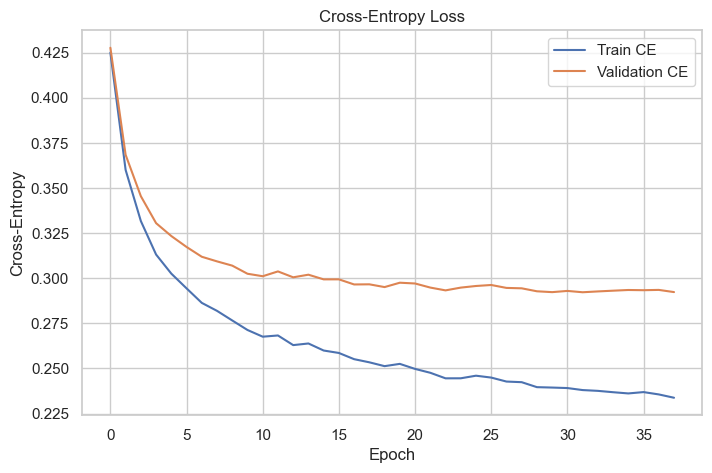

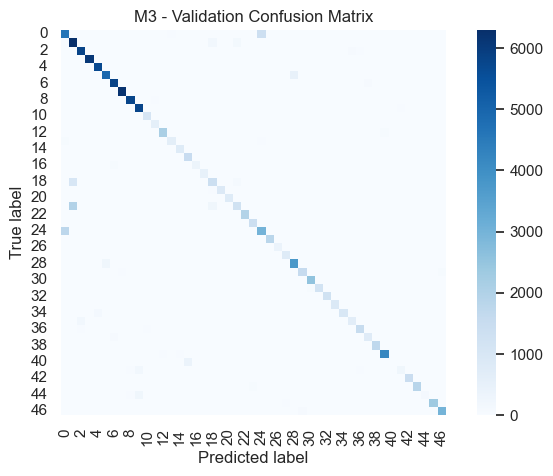

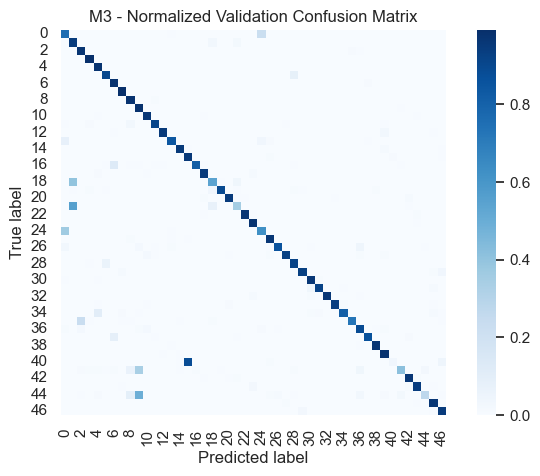

In [ ]:
M3 = TorchMLPClassifier(**best_M3_model_kwargs)
result_M3, history_M3 = train_and_evaluate_torch_model(
    model_name="M3",
    implementation="Best G-Search Torch",
    model=M3,
    X_train=X_train_flat,
    y_train=y_train_one_hot,
    X_val=X_val_flat,
    y_val=y_val_one_hot,
    train_config=best_M3_fit_kwargs,
    plot=True
)

Claramente se pueden observar mejoras en la performances. En primer lugar, las curvas de pérdida son más suaves y particularmente se nota más en validación, siendo casi monótona decreciente hasta estancarse y "abandonar" la tendencia que marcaba la pérdida en train. Este punto en que el gap comienza a crecer significativamente nos indica que el modelo arranca a overfittear, pero gracias a la implementación de dropout y activación silu, el sobreajuste arrancó más tarde que en M1 y M2, llegando a entrenar durante más de 30 epochs frente a las 16 de los modelos mencionados. El modelo generaliza mejor y eso se ve en la mejora de las métricas de validación, de todas formas el veredicto final será dado por la evaluación en test.

### c) Comparar la performance sobre el conjunto de test de los siguientes cuatro modelos:
1) El modelo base de implementación propia (M0).
2) La mejor arquitectura obtenida con la implementación propia (M1).
3) Modelo en PyTorch, usando la misma arquitectura e hiperparámetros que en la implementación propia (M2).
4) La mejor arquitectura obtenida en PyTorch (M3).
---

Los modelos fueron seleccionados utilizando el conjunto de validación. Una vez fijada la configuración final de cada modelo, se evaluó su capacidad de generalización sobre el conjunto de test, que no fue utilizado durante entrenamiento ni selección de hiperparámetros.

In [ ]:
test_M0 = M0.evaluate(X_test_flat, y_test_one_hot)
test_M1 = M1.evaluate(X_test_flat, y_test_one_hot)
test_M2 = evaluate_torch_model(M2, X_test_flat, y_test_one_hot, compute_confusion=True)
test_M3 = evaluate_torch_model(M3, X_test_flat, y_test_one_hot, compute_confusion=True)
results_table = pd.DataFrame(
    [test_M0, test_M1, test_M2, test_M3],
    index=["M0", "M1", "M2", "M3"]
)
results_table = results_table.drop(columns=["confusion_matrix"])
results_table.to_csv("../results/results_test.csv", index=False)
results_table

,cross_entropy,accuracy,f1_macro
M0,3.856105,0.050733,0.009318
M1,0.331498,0.883995,0.856439
M2,0.329513,0.885831,0.858556
M3,0.299858,0.891174,0.861058


Los resultados muestran que el modelo base M0 no logra aprender adecuadamente gracias a la simpleza de su arquitectura, mientras que M1 mejora sustancialmente gracias a las técnicas avanzadas de entrenamiento. M2 reproduce de forma muy cercana el comportamiento de M1 usando PyTorch, validando la implementación propia. Finalmente, M3 obtiene la mejor performance global, con menor cross-entropy y mayor accuracy/F1, aunque con una mejora incremental respecto de M2.

### d) Con los modelos ya entrenados, perturbar los datos de test con distintos niveles de ruido y evaluar cuan robusta es la performance de cada modelo frente a estos datos perturbados en comparacion a los resultados obtenidos de datos sin perturbar.
---

In [50]:
models_info = [
    {
        "name": "M0",
        "implementation": "NumPy propia",
        "model": M0,
        "model_type": "numpy"
    },
    {
        "name": "M1",
        "implementation": "NumPy propia",
        "model": M1,
        "model_type": "numpy"
    },
    {
        "name": "M2",
        "implementation": "PyTorch",
        "model": M2,
        "model_type": "torch"
    },
    {
        "name": "M3",
        "implementation": "PyTorch",
        "model": M3,
        "model_type": "torch"
    }
]
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
robustness_table = evaluate_noise_robustness(
    models_info=models_info,
    X_test=X_test_flat,
    y_test=y_test_one_hot,
    noise_levels=noise_levels
)

In [51]:
robustness_table.to_csv("../results/results_noise_robustness.csv", index=False)
robustness_table

,Model,Implementation,Noise Std,Test CE,Test Accuracy,Test F1 Macro,Clean Test CE,Clean Test Accuracy,Clean Test F1 Macro,CE Increase,Accuracy Drop,F1 Drop
0,M0,NumPy propia,0.00,3.856105,0.050733,0.009318,3.856105,0.050733,0.009318,0.000000,0.000000,0.000000
1,M1,NumPy propia,0.00,0.331498,0.883995,0.856439,0.331498,0.883995,0.856439,0.000000,0.000000,0.000000
2,M2,PyTorch,0.00,0.329513,0.885831,0.858556,0.329513,0.885831,0.858556,0.000000,0.000000,0.000000
3,M3,PyTorch,0.00,0.299858,0.891174,0.861058,0.299858,0.891174,0.861058,0.000000,0.000000,0.000000
4,M0,NumPy propia,0.05,3.854816,0.048486,0.009586,3.856105,0.050733,0.009318,-0.001290,0.002247,-0.000269
5,M1,NumPy propia,0.05,0.378328,0.870166,0.837850,0.331498,0.883995,0.856439,0.046830,0.013830,0.018588
6,M2,PyTorch,0.05,0.381234,0.869532,0.836212,0.329513,0.885831,0.858556,0.051720,0.016299,0.022343
7,M3,PyTorch,0.05,0.356766,0.875945,0.837403,0.299858,0.891174,0.861058,0.056909,0.015229,0.023656
8,M0,NumPy propia,0.10,3.854427,0.047004,0.010162,3.856105,0.050733,0.009318,-0.001679,0.003729,-0.000844
9,M1,NumPy propia,0.10,0.704213,0.764970,0.706569,0.331498,0.883995,0.856439,0.372715,0.119026,0.149869


M0 no es informativo para robustez, porque ya parte de una performance muy baja en test limpio: accuracy $\approx 0.05$ y F1 $\approx 0.009$. Como prácticamente no aprendió, su caída frente al ruido es pequeña en términos absolutos, pero eso no significa que sea robusto; significa que ya estaba cerca del rendimiento aleatorio.

Entre los modelos útiles, M1 y M2 tienen comportamientos muy parecidos, lo cual valida bien la comparación esperada entre la implementación propia y PyTorch. En test limpio ambos están cerca de $0.884;0.886$ de accuracy y $0.856;0.859$ de F1, y frente al ruido caen de manera similar.

M2 parece levemente más robusto que M1 en niveles altos de ruido. Por ejemplo, con ruido $0.30$, M1 cae a accuracy $\approx 0.100$, mientras que M2 cae a $\approx 0.129$. También su F1 queda algo mejor: M2 $\approx 0.129$ contra M1 $\approx 0.112$.

M3 es el mejor modelo en datos limpios, con accuracy $\approx 0.891$ y menor CE $\approx 0.300$. Sin embargo, no es el más robusto al ruido: a partir de ruido $0.10$ empieza a degradarse más fuerte que M1/M2, y con ruido $0.30$ termina con accuracy $\approx 0.103$ y F1 $\approx 0.087$, peor que M2.